In [12]:
# ================================
# 1. Import Libraries
# ================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import numpy as np
import torch
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from transformers import BertTokenizer, BertModel
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
# ================================
# 2. Download NLTK Resources
# ================================
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\20155\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\20155\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\20155\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# ================================
# 3. Load Dataset
# ================================

import pandas as pd

# Load training dataset
train_df = pd.read_csv('train.tsv', sep='\t')

# Load validation dataset
validation_df = pd.read_csv('validation.tsv', sep='\t')

In [4]:
# ================================
# 4. Handle Missing Values
# ================================

# Clean the training data
train_df.dropna(subset=['tweet', 'label'], inplace=True)

# Clean the validation data
validation_df.dropna(subset=['tweet', 'label'], inplace=True)

# Optional: Verify the results
print(f"Train size: {len(train_df)}")
print(f"Validation size: {len(validation_df)}")

Train size: 2999
Validation size: 1500


In [ ]:
# =========================================================
# 5. TEXT CLEANING FUNCTION
# =========================================================
def clean_text(text):
    """
    Clean raw text by:
    - Lowercasing
    - Removing URLs
    - Removing special characters
    - Removing extra spaces
    """
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)          # Remove URLs
    text = re.sub(r'[^a-zA-Z\s]', '', text)      # Keep only letters , Remove specila character
    text = re.sub(r'\s+', ' ', text).strip()     # Remove extra spaces
    return text


# Apply cleaning
train_df['processed_text'] = train_df['tweet'].apply(clean_text)
validation_df['processed_text'] = validation_df['tweet'].apply(clean_text)

In [6]:

# =========================================================
# 6. TF-IDF + KEYWORD FEATURES
# =========================================================
# Convert text into numerical features using TF-IDF
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.9
)

X_tfidf = tfidf.fit_transform(train_df['processed_text'])

# Define domain-specific abuse keywords
abuse_keywords = [
    "hit", "beaten", "abuse", "hurt", "injury",
    "bruise", "bleeding", "cry", "fear",
    "violence", "neglect", "pain"
]

def extract_keyword_features(text):
    """
    Create binary features indicating presence of abuse-related keywords
    """
    return [int(word in text) for word in abuse_keywords]

# Convert keyword features to array
kw_features = np.array(
    train_df['processed_text'].apply(extract_keyword_features).tolist()
)

# Combine TF-IDF features with keyword features
X_combined = hstack([X_tfidf, kw_features])


In [7]:

# =========================================================
# 7. TRAIN-TEST SPLIT (TF-IDF MODEL)
# =========================================================
y = train_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train Logistic Regression model
tfidf_model = LogisticRegression(max_iter=1000)
tfidf_model.fit(X_train, y_train)

# Predictions
tfidf_predictions = tfidf_model.predict(X_test)

In [ ]:

# =========================================================
# 8. BERT FEATURE EXTRACTION
# =========================================================
# Load pre-trained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

def get_bert_embedding(text):
    """
    Bidirectional Encoder Representation Transformer 
    bert base uncaase
    cls token 

    Extract CLS embedding from BERT
    (represents the entire sentence)
    """
    inputs = tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=128
    )

    with torch.no_grad():
        outputs = bert_model(**inputs)

    # CLS token embedding
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()


print("\nExtracting BERT embeddings (this may take time)...")

# Use subset for faster execution
X_bert = np.array([
    get_bert_embedding(text)
    for text in train_df['processed_text'].head(500)
])

y_bert = train_df['label'].head(500)

# Split BERT features
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bert,
    y_bert,
    test_size=0.2,
    random_state=42,
    stratify=y_bert
)

# Train model on BERT embeddings
bert_model_lr = LogisticRegression(max_iter=1000)
bert_model_lr.fit(Xb_train, yb_train)

bert_predictions = bert_model_lr.predict(Xb_test)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Extracting BERT embeddings (this may take time)...


In [9]:

# =========================================================
# 9. MODEL EVALUATION FUNCTION
# =========================================================
def evaluate_model(y_true, y_pred, model_name="Model"):
    """
    Evaluate classification model using multiple metrics
    (supports multiclass classification)
    """
    print(f"\n{'='*20} {model_name} {'='*20}")

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f} (weighted)")
    print(f"Recall   : {rec:.4f} (weighted)")
    print(f"F1 Score : {f1:.4f} (weighted)")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))


In [10]:
# =========================================================
# 10. RUN EVALUATION
# =========================================================
evaluate_model(y_test, tfidf_predictions, "TF-IDF + Logistic Regression")
evaluate_model(yb_test, bert_predictions, "BERT + Logistic Regression")


==================== TF-IDF + Logistic Regression ====================
Accuracy : 0.9617
Precision: 0.9248 (weighted)
Recall   : 0.9617 (weighted)
F1 Score : 0.9429 (weighted)

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00        16
           3       0.96      1.00      0.98       577

    accuracy                           0.96       600
   macro avg       0.32      0.33      0.33       600
weighted avg       0.92      0.96      0.94       600

Confusion Matrix:
[[  0   0   7]
 [  0   0  16]
 [  0   0 577]]

==================== BERT + Logistic Regression ====================
Accuracy : 0.9500
Precision: 0.9116 (weighted)
Recall   : 0.9500 (weighted)
F1 Score : 0.9304 (weighted)

Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.00      0.00      0.00   

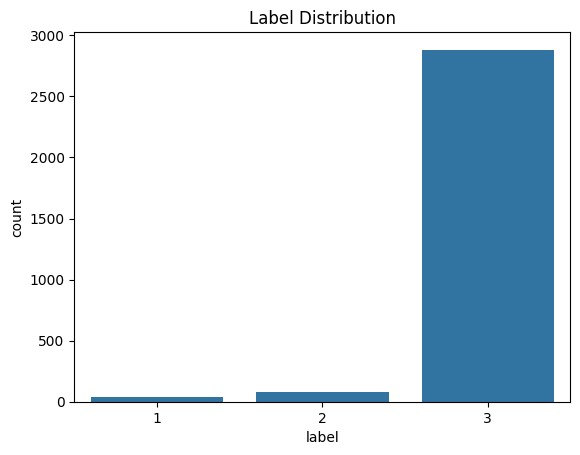

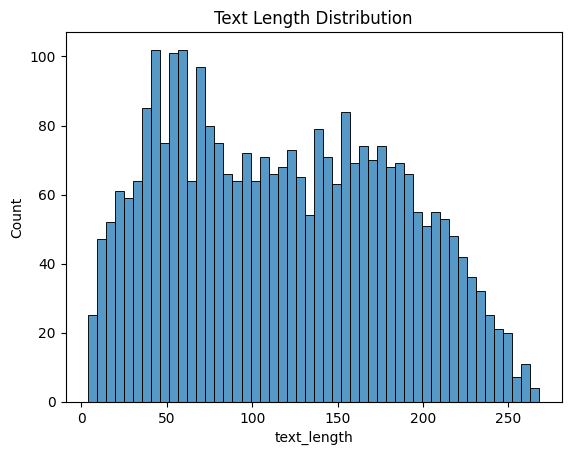

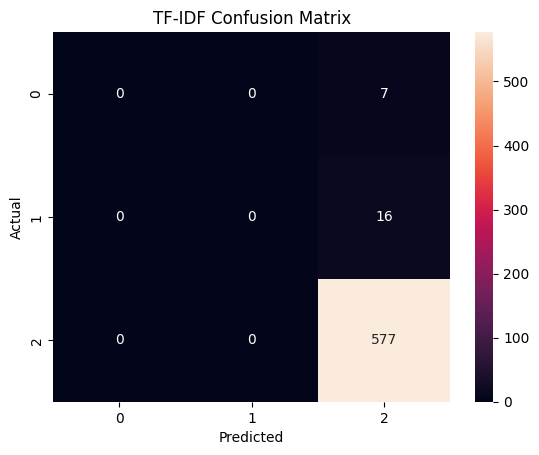

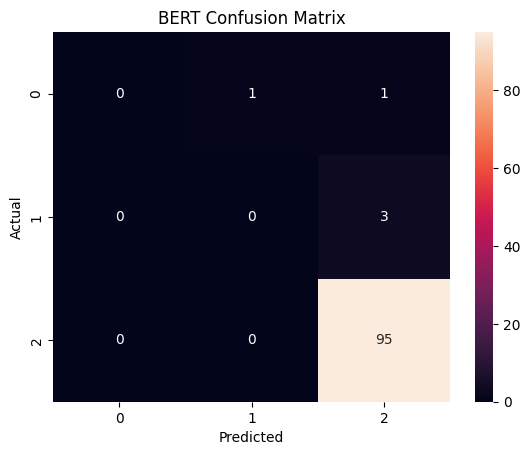

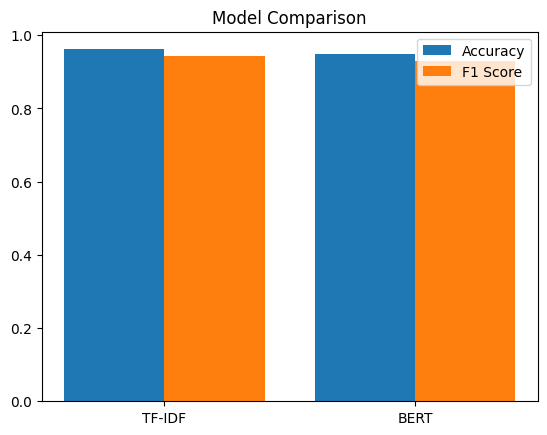

In [ ]:
# =========================================================
# 11. VISUALIZATION
# =========================================================

# ---- 11.1 Label Distribution ----
plt.figure()
sns.countplot(x=train_df['label'])
plt.title("Label Distribution")
plt.show()


# ---- 11.2 Text Length Distribution ----
train_df['text_length'] = train_df['processed_text'].apply(len)

plt.figure()
sns.histplot(train_df['text_length'], bins=50)
plt.title("Text Length Distribution")
plt.show()


# ---- 11.3 Confusion Matrix (TF-IDF) ----
plt.figure()
sns.heatmap(confusion_matrix(y_test, tfidf_predictions), annot=True, fmt='d')
plt.title("TF-IDF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ---- 11.4 Confusion Matrix (BERT) ----
plt.figure()
sns.heatmap(confusion_matrix(yb_test, bert_predictions), annot=True, fmt='d')
plt.title("BERT Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


# ---- 11.5 Model Comparison ----
models = ["TF-IDF", "BERT"]

accuracy_scores = [
    accuracy_score(y_test, tfidf_predictions),
    accuracy_score(yb_test, bert_predictions)
]

f1_scores = [
    f1_score(y_test, tfidf_predictions, average='weighted'),
    f1_score(yb_test, bert_predictions, average='weighted')
]

x = np.arange(len(models))

plt.figure()
plt.bar(x - 0.2, accuracy_scores, 0.4, label='Accuracy')
plt.bar(x + 0.2, f1_scores, 0.4, label='F1 Score')
plt.xticks(x, models)
plt.title("Model Comparison")
plt.legend()
plt.show()

In [13]:
import joblib
joblib.dump(bert_model_lr, 'bert_classifier.pkl')

['bert_classifier.pkl']